In [4]:
# Package imports
import numpy as np                                  # "Scientific computing"
import pandas as pd                                 # Dataframe

import scipy.stats as stats                         # Statistical tests
from sklearn.linear_model import LinearRegression   # Linear regression model

import matplotlib.pyplot as plt                     # Basic visualisation
from statsmodels.graphics.mosaicplot import mosaic  # Mosaic plot
import seaborn as sns                               # Advanced dataviz

# Datum of tijd

In [2]:
# Read the data from CSV, parse dates and set the index
wounded_data = pd.read_csv(
    'https://raw.githubusercontent.com/HoGentTIN/dsai-en-labs/main/data/number_of_heavily_wounded_car_accidents_VL.txt',
    delimiter = "\t",
    parse_dates=['date']).set_index(['date'])

# Add frequency info to the index
wounded_data.index = pd.DatetimeIndex(wounded_data.index, freq='MS')

wounded_data.head()

,number_of_heavily_wounded
date,
2013-01-01,285
2013-02-01,276
2013-03-01,332
2013-04-01,381
2013-05-01,393


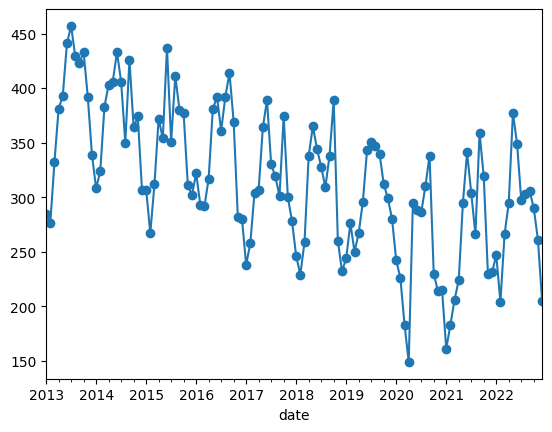

In [3]:
wounded_ts = pd.Series(
    data=np.array(wounded_data['number_of_heavily_wounded']),
    index=wounded_data.index
)
wounded_ts.plot(marker='o');

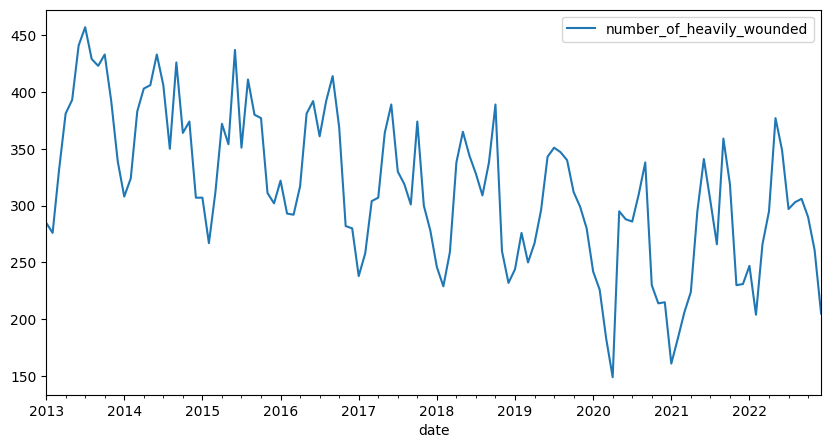

In [4]:
wounded_data.plot( y='number_of_heavily_wounded', figsize=[10,5]);


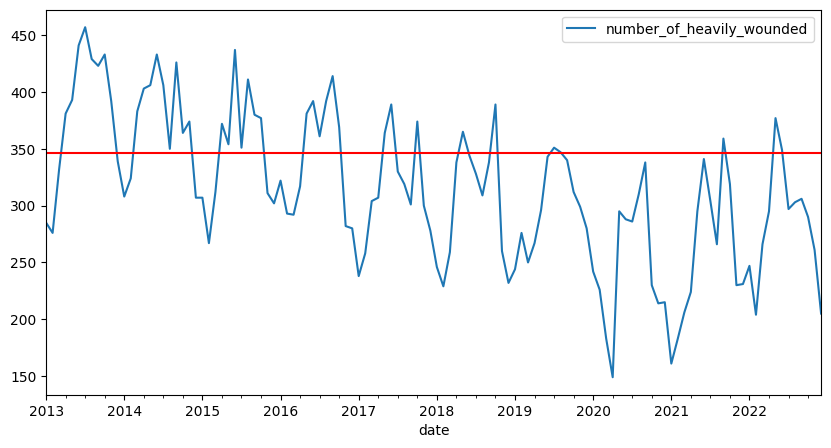

In [5]:
b_est_70 = wounded_data['number_of_heavily_wounded'].head(70).mean()

wounded_data.plot(y='number_of_heavily_wounded', figsize=[10,5]);
plt.axhline(y=b_est_70, color='red');   # Mean of first 70 observations

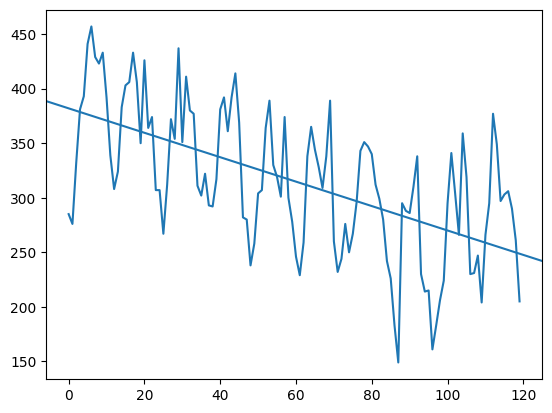

In [6]:
# Build a linear regression model
wounded_lm = LinearRegression().fit(
    np.arange(0,120).reshape((-1,1)),
    wounded_data['number_of_heavily_wounded'].values
)

# plot the time series and the regression line
plt.plot(np.arange(0,120), wounded_data['number_of_heavily_wounded']);
plt.axline((0, wounded_lm.intercept_), slope=wounded_lm.coef_[0]);

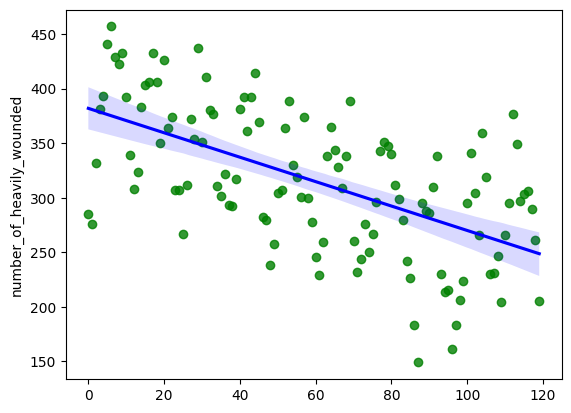

In [7]:
sns.regplot(
    x=np.arange(0,120),
    y=wounded_data['number_of_heavily_wounded'],
    line_kws={'color': 'b'},
    scatter_kws={'color':'g'});

Hier heb je niks aan (Manier van H6 om H7 grafieken te berekenen)